#  Climate Change and Extreme Weather Events

**Research Question:** How have the frequency and economic damage of extreme weather events changed
over the past 50 years, and which world regions show the steepest acceleration?

## 1. Configuração e Obtenção de Dados

In [178]:
# Bibliotecas
import os
import glob
import pandas as pd
import seaborn as sns
import missingno as msno
import plotly.express as px
import pycountry_convert as pc
import matplotlib.pyplot as plt

In [179]:
# Funções
# Filtrar apenas os dados relativos a regiões (continentes) do planeta
def country_to_continent(country_code):
    # TLS: Timor-Leste (Asia), SXM: Sint Maarten (North America)
    # YMN: Yemen Arab Republic (Asia), DFR: Germany Federal Republic (Europe)
    # YMD: People's Democratic Republic of Yemen (Asia), YUG: Yugoslavia (Europe)
    # CSK: Czechoslovakia (Europe), SUN: Soviet Union (Europe),
    # DDR: German Democratic Republic (Europe), AZO: Azores Islands (Europe)
    # ANT: Netherlands Antilles (South America), SCG: Serbia Montenegro (Europe)
    # SPI: Canary Islands (Africa)

    ukn_asia = ['YMN', 'TLS', 'YMD']
    ukn_europe = ['AZO', 'DFR', 'YUG', 'CSK', 'SUN', 'DDR', 'SCG']
    try:
        country_code_alpha2 = pc.country_alpha3_to_country_alpha2(country_code)
        continent_code = pc.country_alpha2_to_continent_code(country_code_alpha2)
        continent_name = pc.convert_continent_code_to_continent_name(continent_code)
        return continent_name
    except Exception:
        if country_code == 'SPI':
            return "Africa"
        if country_code in ukn_asia:
            return "Asia"
        if country_code in ukn_europe:
            return "Europe"
        if country_code == 'ANT':
            return "South America"
        if country_code == 'SXM':
            return "North America"
        print(f"Erro ao converter {country_code}.")
        return "Other/Unknown"
    
# Exibir a quantidade e a porcentagem de valores ausentes por coluna
def show_missing_values(df):
    missing = df.isnull().sum()
    pct = (missing / len(df) * 100).round(1)
    summary = pd.DataFrame({
        'missing_count': missing,
        'missing_pct': pct
    })

    if summary['missing_count'].sum() == 0:
        print("Não há valores ausentes no dataset.")
    else:
        print("Valores ausentes por coluna:")
        print(summary[summary['missing_count'] > 0])

# Exibir a quantidade e a porcentagem de linhas duplicadas
def show_duplicate_lines(df):
    n_duplicates = df.duplicated().sum()
    duplicates_per = n_duplicates/len(df) * 100

    print(f"Linhas duplicadas: {n_duplicates} ({duplicates_per:.2f}%)")

In [180]:
path = '../data'
files = glob.glob(os.path.join(path, "*.csv"))
df_list = [pd.read_csv(f) for f in files]

extreme_weather_events   = df_list[0]
greenhouse_gas_emissions = df_list[1]
surface_temperature      = df_list[2]
temperature_anomalies    = df_list[3]

## 2. Limpeza e Filtragem (Data Cleaning)

* **Tipos de Eventos:** Droughts, Floods, Storms, Extreme Temperatures e Wildfires.
* **Recorte Temporal:** 1975 a 2024 (50 anos).
* **Agrupamento Geográfico:** África, Ásia, Europa, América do Norte, América do Sul e Oceania.

### 2.1. Análise do dataset **Extreme weather events**

Pre-2000 data is particularly subject to reporting biases.

In [181]:
rows, cols = extreme_weather_events.shape

print(f"O dataframe tem: {rows} linhas e {cols} colunas.")

show_duplicate_lines(extreme_weather_events)

print(extreme_weather_events.columns.to_list())

O dataframe tem: 11768 linhas e 8 colunas.
Linhas duplicadas: 157 (1.33%)
['Year', 'Disaster Type', 'ISO', 'Country', 'Region', 'Total Deaths', 'Total Affected', 'Adjusted Total Damage (K US$)']


In [182]:
print(extreme_weather_events.Region.unique().tolist())
display(extreme_weather_events)

['Africa', 'Asia', 'Oceania', 'Americas', 'Europe']


,Year,Disaster Type,ISO,Country,Region,Total Deaths,Total Affected,Adjusted Total Damage (K US$)
0,1975,Flood,KEN,Kenya,Africa,NaN,16000.0,NaN
1,1975,Flood,THA,Thailand,Asia,239.0,3000093.0,262298.0
2,1975,Storm,MDG,Madagascar,Africa,7.0,10050.0,NaN
3,1975,Storm,FJI,Fiji,Oceania,NaN,23000.0,5829.0
4,1975,Flood,MOZ,Mozambique,Africa,1.0,75000.0,NaN
...,...,...,...,...,...,...,...,...
11763,2000,Storm,REU,Réunion,Africa,2.0,600.0,NaN
11764,2000,Storm,IRN,Iran (Islamic Republic of),Asia,3.0,5500.0,NaN
11765,1999,Drought,UGA,Uganda,Africa,115.0,700000.0,NaN
11766,2000,Drought,SOM,Somalia,Africa,21.0,1200000.0,NaN


Como este dataset não faz a distinção entre América do Norte e do Sul, precisamos fazer uma tranformação, como base no código ISO dos países, mas que esta divisão fique correta. Em seguida eliminamos as colunas ISO e Country, para facilitar os processos seguintes.

In [183]:
extreme_weather_events['Region'] = extreme_weather_events['ISO'].apply(country_to_continent)
print(extreme_weather_events.Region.unique().tolist())
extreme_weather_events.drop(columns=['ISO', 'Country'], inplace=True)

extreme_weather_events.info()
display(extreme_weather_events.describe())
display(extreme_weather_events)

['Africa', 'Asia', 'Oceania', 'North America', 'South America', 'Europe']
<class 'pandas.DataFrame'>
RangeIndex: 11768 entries, 0 to 11767
Data columns (total 6 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Year                           11768 non-null  int64  
 1   Disaster Type                  11768 non-null  str    
 2   Region                         11768 non-null  str    
 3   Total Deaths                   8131 non-null   float64
 4   Total Affected                 8926 non-null   float64
 5   Adjusted Total Damage (K US$)  4413 non-null   float64
dtypes: float64(3), int64(1), str(2)
memory usage: 551.8 KB


,Year,Total Deaths,Total Affected,Adjusted Total Damage (K US$)
count,11768.000000,8131.000000,8.926000e+03,4.413000e+03
mean,2005.213970,218.409913,8.923259e+05,1.244044e+06
std,12.672943,4564.128323,8.470675e+06,5.658013e+06
min,1975.000000,1.000000,1.000000e+00,6.000000e+00
25%,1997.000000,4.000000,1.013500e+03,2.246200e+04
50%,2006.000000,13.000000,1.000000e+04,1.500000e+05
75%,2016.000000,40.000000,9.979625e+04,7.204930e+05
max,2024.000000,300000.000000,3.300000e+08,2.007823e+08


,Year,Disaster Type,Region,Total Deaths,Total Affected,Adjusted Total Damage (K US$)
0,1975,Flood,Africa,NaN,16000.0,NaN
1,1975,Flood,Asia,239.0,3000093.0,262298.0
2,1975,Storm,Africa,7.0,10050.0,NaN
3,1975,Storm,Oceania,NaN,23000.0,5829.0
4,1975,Flood,Africa,1.0,75000.0,NaN
...,...,...,...,...,...,...
11763,2000,Storm,Africa,2.0,600.0,NaN
11764,2000,Storm,Asia,3.0,5500.0,NaN
11765,1999,Drought,Africa,115.0,700000.0,NaN
11766,2000,Drought,Africa,21.0,1200000.0,NaN


In [184]:
show_missing_values(extreme_weather_events)

Valores ausentes por coluna:
                               missing_count  missing_pct
Total Deaths                            3637         30.9
Total Affected                          2842         24.2
Adjusted Total Damage (K US$)           7355         62.5


<Axes: >

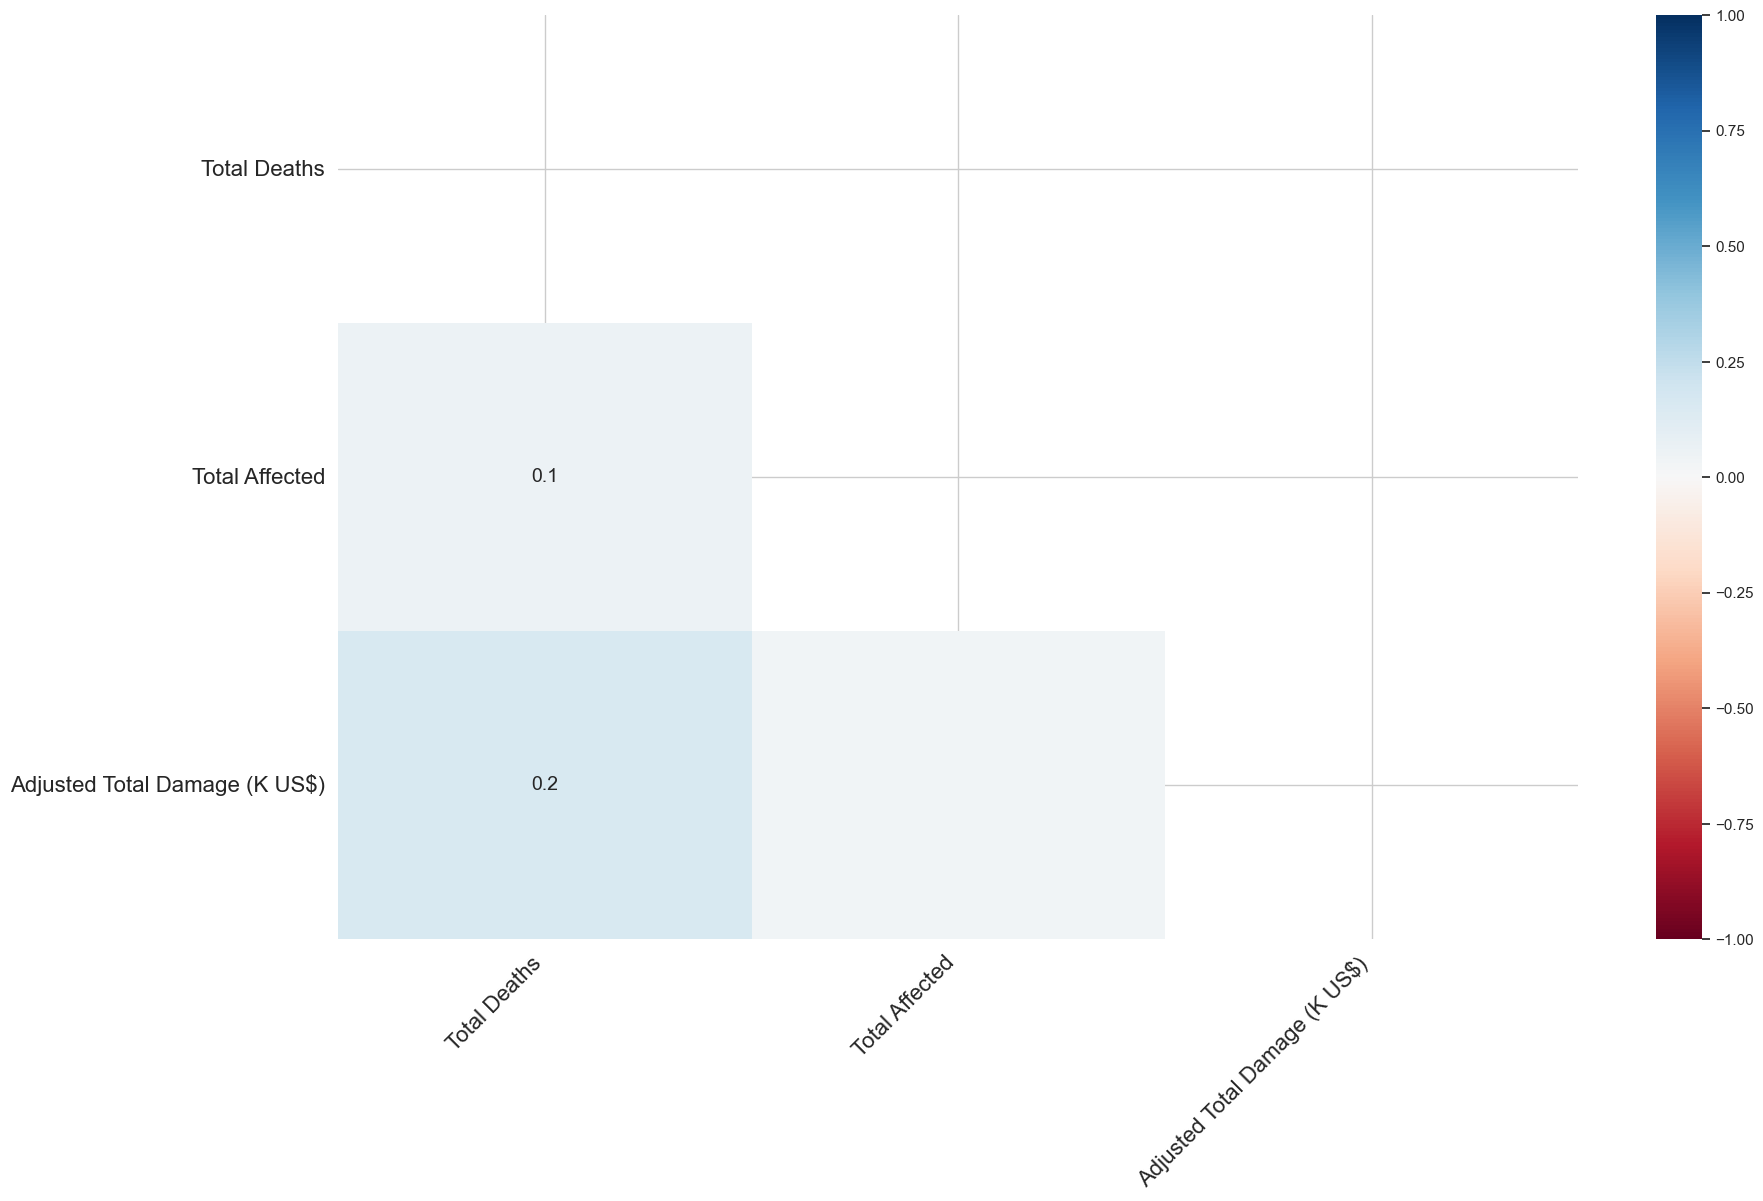

In [185]:
msno.heatmap(extreme_weather_events)

Ao analisar o heatmap acima, chegamos à conclusão que, devido aos valores próximos de 0 (zero), podemos afirmar que não há relação entre a ausência de dados das colunas.

Para melhor analisar os efeitos dos eventos climáticos extremos, resolvemos separá-los de acordo com o impacto causado (Total Deaths, Total Affected e Adjusted Total Damage).

In [186]:
ewe_deaths = extreme_weather_events.drop(columns=['Total Affected', 'Adjusted Total Damage (K US$)'])
ewe_affected = extreme_weather_events.drop(columns=['Total Deaths', 'Adjusted Total Damage (K US$)'])
ewe_damage = extreme_weather_events.drop(columns=['Total Deaths', 'Total Affected'])

#### 2.1.1 Análise do subdataset **Extreme weather events - Total Deaths**

In [187]:
show_missing_values(ewe_deaths)

Valores ausentes por coluna:
              missing_count  missing_pct
Total Deaths           3637         30.9


Este subdataset tem 3.637 valores vazios (30.9%). Contudo, como nem todo evento causa mortes, resolvemos preencher os valores vazios com 0 (zero), indicando que não houve mortes nestes desastres.

In [188]:
ewe_deaths = ewe_deaths.fillna(0)
ewe_deaths['Total Deaths'] = ewe_deaths['Total Deaths'].astype(int)
show_missing_values(ewe_deaths)
display(ewe_deaths.head())

ewe_deaths_1 = ewe_deaths.groupby(['Year', 'Region', 'Disaster Type'])['Total Deaths'].sum()
ewe_deaths_1 = ewe_deaths_1.unstack(fill_value=0).reset_index().rename_axis(None, axis=1)

ewe_deaths_1.info()
display(ewe_deaths_1.describe())
display(ewe_deaths_1)

Não há valores ausentes no dataset.


,Year,Disaster Type,Region,Total Deaths
0,1975,Flood,Africa,0
1,1975,Flood,Asia,239
2,1975,Storm,Africa,7
3,1975,Storm,Oceania,0
4,1975,Flood,Africa,1


<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Year                 300 non-null    int64
 1   Region               300 non-null    str  
 2   Drought              300 non-null    int64
 3   Extreme temperature  300 non-null    int64
 4   Flood                300 non-null    int64
 5   Storm                300 non-null    int64
 6   Wildfire             300 non-null    int64
dtypes: int64(6), str(1)
memory usage: 16.5 KB


,Year,Drought,Extreme temperature,Flood,Storm,Wildfire
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,1999.500000,1948.713333,1227.246667,1048.893333,1683.146667,11.636667
std,14.454981,26679.969577,7767.749344,2647.695393,11802.557012,29.120290
min,1975.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1987.000000,0.000000,0.000000,36.750000,12.000000,0.000000
50%,1999.500000,0.000000,0.000000,161.000000,67.500000,0.000000
75%,2012.000000,0.000000,150.250000,698.250000,436.000000,9.250000
max,2024.000000,450500.000000,72225.000000,30127.000000,146055.000000,240.000000


,Year,Region,Drought,Extreme temperature,Flood,Storm,Wildfire
0,1975,Africa,0,0,26,28,0
1,1975,Asia,0,14,20644,822,0
2,1975,Europe,0,0,60,0,0
3,1975,North America,0,0,0,171,0
4,1975,Oceania,0,0,0,0,0
...,...,...,...,...,...,...,...
295,2024,Asia,0,4283,2669,1663,4
296,2024,Europe,0,62557,275,60,10
297,2024,North America,0,1161,63,570,5
298,2024,Oceania,0,0,2,1,0


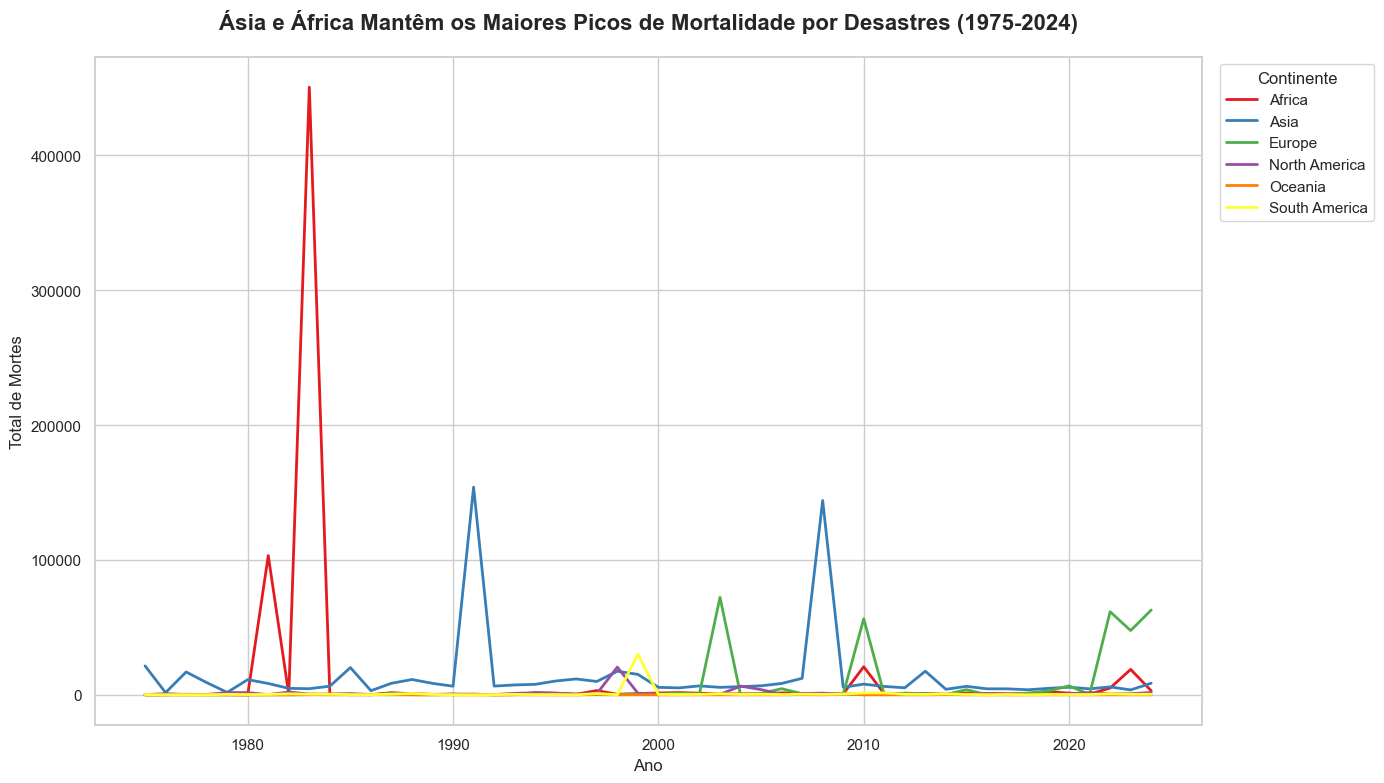

In [189]:
# 1. Preparar os dados de mortalidade por Região
deaths_region = ewe_deaths.groupby(['Year', 'Region'])['Total Deaths'].sum().reset_index()

plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid") # Adiciona grades para facilitar a leitura

fig_region = sns.lineplot(
    data=deaths_region, 
    x='Year', 
    y='Total Deaths', 
    hue='Region',
    markers='o',
    markersize=4,
    linewidth=2,
    palette='Set1'
)

#Customização e Títulos
plt.title('Ásia e África Mantêm os Maiores Picos de Mortalidade por Desastres (1975-2024)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Total de Mortes', fontsize=12)

plt.legend(title='Continente', title_fontsize='12', fontsize='11', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

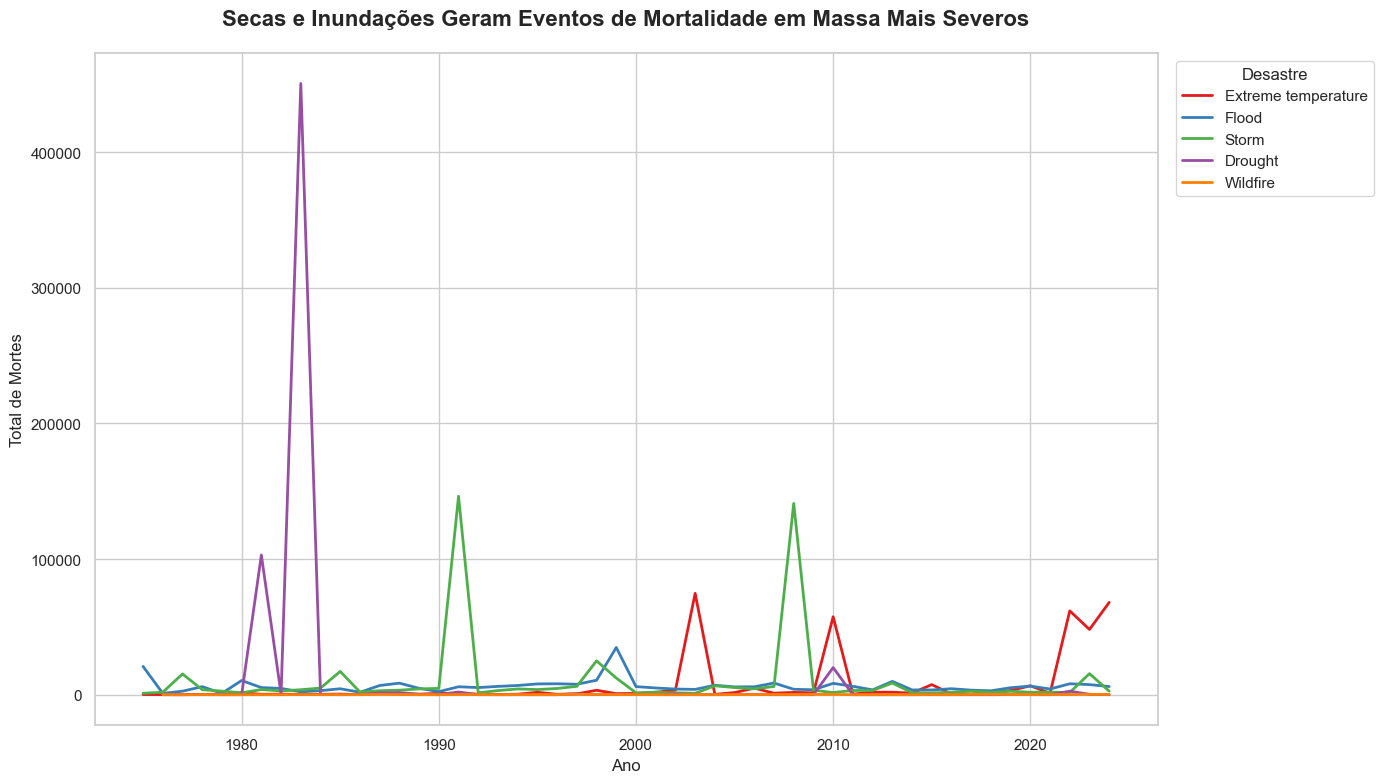

In [190]:
# 2. Preparar os dados de mortalidade por Tipo de Desastre
deaths_type = ewe_deaths.groupby(['Year', 'Disaster Type'])['Total Deaths'].sum().reset_index()

plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid") # Adiciona grades para facilitar a leitura

fig_region = sns.lineplot(
    data=deaths_type, 
    x='Year', 
    y='Total Deaths', 
    hue='Disaster Type',
    markers='o',
    markersize=4,
    linewidth=2,
    palette='Set1'
)

#Customização e Títulos
plt.title('Secas e Inundações Geram Eventos de Mortalidade em Massa Mais Severos', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Total de Mortes', fontsize=12)

plt.legend(title='Desastre', title_fontsize='12', fontsize='11', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

#### 2.1.2 Análise do subdataset **Extreme weather events - Total Affected**

In [191]:
show_missing_values(ewe_affected)

Valores ausentes por coluna:
                missing_count  missing_pct
Total Affected           2842         24.2


In [192]:
# Contagem para o período de 1975 a 1999
vazios_75_99 = ewe_affected.loc[ewe_affected['Year'] <= 1999, 'Total Affected'].isna().sum()

# Contagem para o período de 2000 a 2024
vazios_00_24 = ewe_affected.loc[ewe_affected['Year'] >= 2000, 'Total Affected'].isna().sum()

print(f"Linhas vazias (1975-1999): {vazios_75_99}")
print(f"Linhas vazias (2000-2024): {vazios_00_24}")

Linhas vazias (1975-1999): 1164
Linhas vazias (2000-2024): 1678


Apesar do aviso do EM-DAT de que os valores anteriores a 2000 estão mais sujeitos à vieses, como a quantidade de valores vazions na coluna de total de afetados é maior no período após os anos 2000, então passamos a considerar como 0 (zero), a quantidade de pessoas afetadas nos registros vazios.

In [193]:
ewe_affected = ewe_affected.fillna(0)
ewe_affected['Total Affected'] = ewe_affected['Total Affected'].astype(int)
show_missing_values(ewe_affected)
display(ewe_affected.head())

ewe_affected_1 = ewe_affected.groupby(['Year', 'Region', 'Disaster Type'])['Total Affected'].sum()
ewe_affected_1 = ewe_affected_1.unstack(fill_value=0).reset_index().rename_axis(None, axis=1)

ewe_affected_1.info()
display(ewe_affected_1.describe())
display(ewe_affected_1)

Não há valores ausentes no dataset.


,Year,Disaster Type,Region,Total Affected
0,1975,Flood,Africa,16000
1,1975,Flood,Asia,3000093
2,1975,Storm,Africa,10050
3,1975,Storm,Oceania,23000
4,1975,Flood,Africa,75000


<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Year                 300 non-null    int64
 1   Region               300 non-null    str  
 2   Drought              300 non-null    int64
 3   Extreme temperature  300 non-null    int64
 4   Flood                300 non-null    int64
 5   Storm                300 non-null    int64
 6   Wildfire             300 non-null    int64
dtypes: int64(6), str(1)
memory usage: 16.5 KB


,Year,Drought,Extreme temperature,Flood,Storm,Wildfire
count,300.000000,3.000000e+02,3.000000e+02,3.000000e+02,3.000000e+02,3.000000e+02
mean,1999.500000,8.789418e+06,4.702855e+05,1.299922e+07,4.228290e+06,6.245250e+04
std,14.454981,3.647078e+07,5.032289e+06,3.796798e+07,1.199001e+07,6.090032e+05
min,1975.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1987.000000,0.000000e+00,0.000000e+00,4.935650e+04,8.716000e+03,0.000000e+00
50%,1999.500000,2.375000e+04,0.000000e+00,4.173895e+05,1.186205e+05,1.900000e+01
75%,2012.000000,3.637500e+06,2.150000e+02,2.821886e+06,1.323320e+06,3.096000e+03
max,2024.000000,3.715100e+08,7.917068e+07,2.896435e+08,1.093965e+08,1.004294e+07


,Year,Region,Drought,Extreme temperature,Flood,Storm,Wildfire
0,1975,Africa,0,0,248000,846308,0
1,1975,Asia,0,0,48053448,9396,0
2,1975,Europe,0,0,1000000,0,0
3,1975,North America,0,0,0,540,0
4,1975,Oceania,0,0,0,23000,0
...,...,...,...,...,...,...,...
295,2024,Asia,266000,36377795,31898475,40507606,19900
296,2024,Europe,0,0,86657,326000,42399
297,2024,North America,100000,2567,1900177,5060799,7739
298,2024,Oceania,13924,0,6206,25134,0


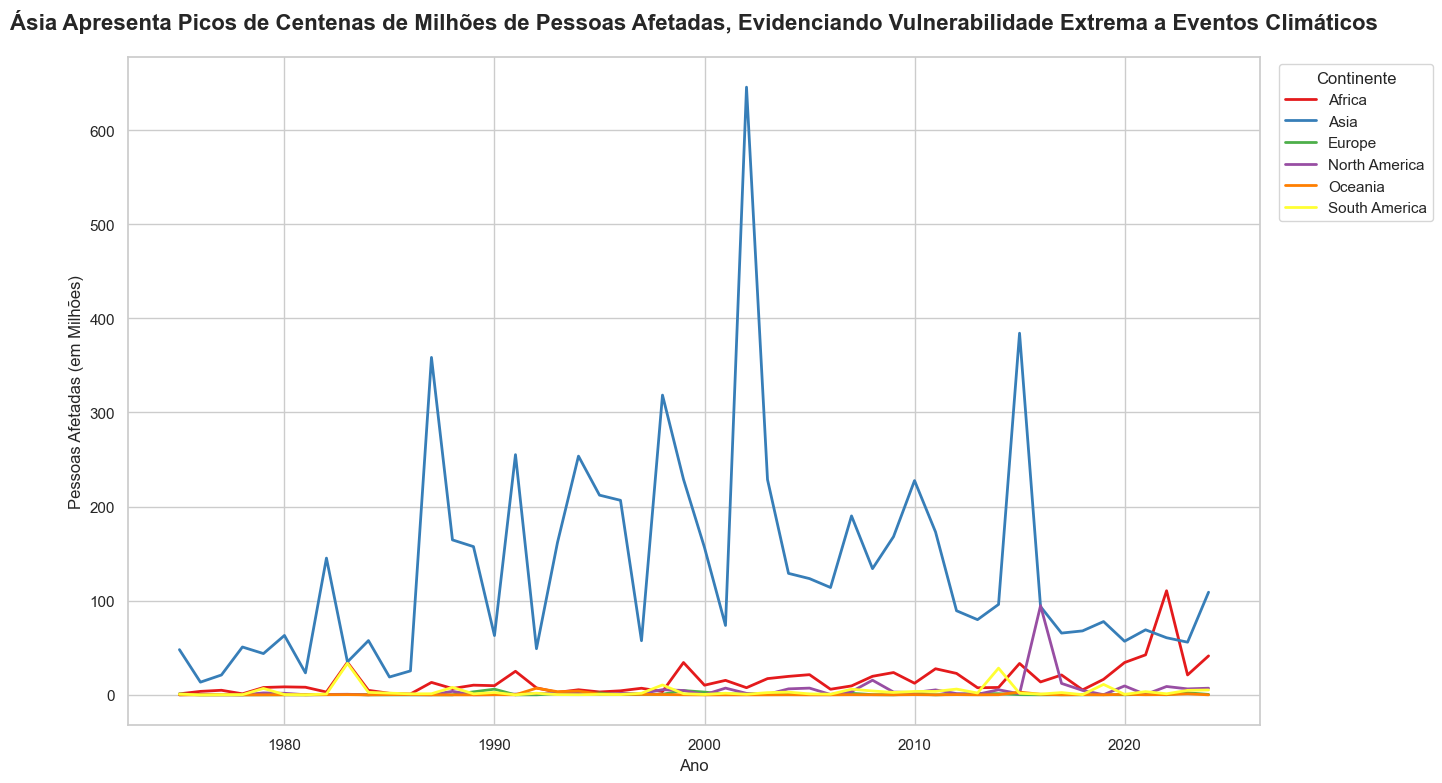

In [194]:
# 1. Preparar os dados de afetados por Região
affected_region = ewe_affected.groupby(['Year', 'Region'])['Total Affected'].sum().reset_index()

# Transformando a unidade para Milhões antes de plotar
affected_region['Total Affected'] = affected_region['Total Affected'] / 1_000_000

plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid") # Adiciona grades para facilitar a leitura

fig_region = sns.lineplot(
    data=affected_region, 
    x='Year', 
    y='Total Affected', 
    hue='Region',
    markers='o',
    markersize=4,
    linewidth=2,
    palette='Set1'
)

#Customização e Títulos
plt.title('Ásia Apresenta Picos de Centenas de Milhões de Pessoas Afetadas, Evidenciando Vulnerabilidade Extrema a Eventos Climáticos', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Pessoas Afetadas (em Milhões)', fontsize=12)

plt.legend(title='Continente', title_fontsize='12', fontsize='11', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

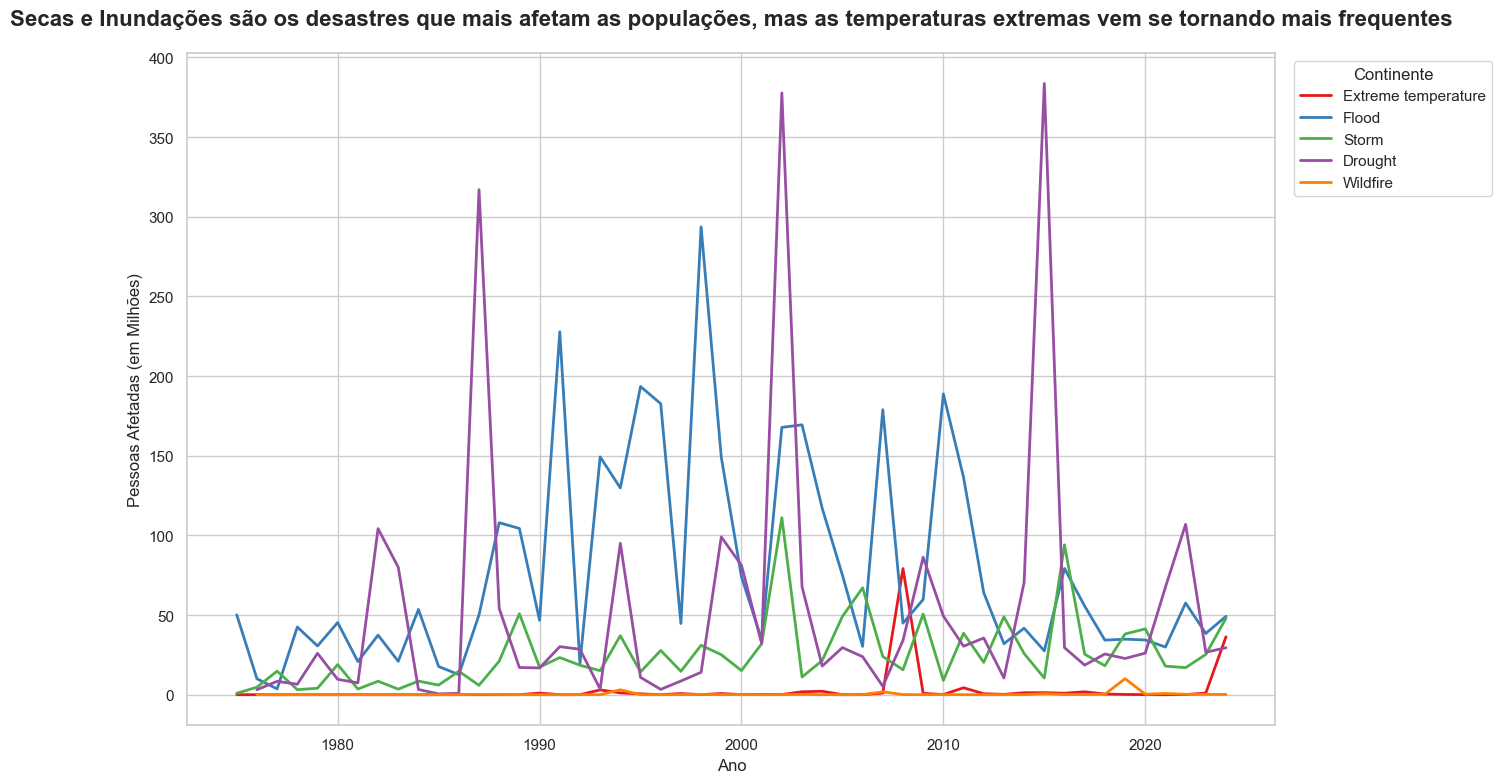

In [195]:
# 2. Preparar os dados de mortalidade por Tipo de Desastre
affected_type = ewe_affected.groupby(['Year', 'Disaster Type'])['Total Affected'].sum().reset_index()

# Transformando a unidade para Milhões antes de plotar
affected_type['Total Affected'] = affected_type['Total Affected'] / 1_000_000

plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid") # Adiciona grades para facilitar a leitura

fig_region = sns.lineplot(
    data=affected_type, 
    x='Year', 
    y='Total Affected', 
    hue='Disaster Type',
    markers='o',
    markersize=4,
    linewidth=2,
    palette='Set1'
)

#Customização e Títulos
plt.title('Secas e Inundações são os desastres que mais afetam as populações, mas as temperaturas extremas vem se tornando mais frequentes', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Pessoas Afetadas (em Milhões)', fontsize=12)

plt.legend(title='Continente', title_fontsize='12', fontsize='11', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

#### 2.1.2 Análise do subdataset **Extreme weather events - Adjusted Total Damage (K US$)**

Procurar os dados do PIB por continente de 2025. https://en.wikipedia.org/wiki/List_of_continents_by_GDP

"GDP (Nominal), current prices". International Monetary Fund. Retrieved 15 November 2025.

In [196]:
countries_gdp = pd.DataFrame({
    "Region": ['Africa', 'Asia', 'Europe', 'North America', 'Oceania', 'South America'],
    "Values (billions US$)": [3_058, 42_188, 29_677, 35_580, 2_137, 4_447]
})

display(countries_gdp)

,Region,Values (billions US$)
0,Africa,3058
1,Asia,42188
2,Europe,29677
3,North America,35580
4,Oceania,2137
5,South America,4447


In [197]:
show_missing_values(ewe_damage)

Valores ausentes por coluna:
                               missing_count  missing_pct
Adjusted Total Damage (K US$)           7355         62.5


Resolvemos preencher os valores vazios com zero pois nem todos os tipos de desastres geram danos econômicos registrados todos os anos em todas as regiões. Assim, não excluímos o registro que o desastre aconteceu, apesar de não ter havido ou sido registrado dano econômico.

In [198]:
# 1. Somar os valores de cada tipo de dano, agrupando por Ano e Região e preenchendo os vazios com 0
economic_damages = ewe_damage.groupby(['Year', 'Region', 'Disaster Type'])['Adjusted Total Damage (K US$)'].sum()
economic_damages = economic_damages.unstack(fill_value=0).reset_index()

# 2. Unir os dataframes pela coluna 'Region'
# Isso trará a coluna 'Values (billions US$)' para o dataframe de danos
economic_damages = pd.merge(economic_damages, countries_gdp[['Region', 'Values (billions US$)']], on='Region')

# 3. Definir as colunas que serão convertidas
disasters = ['Drought', 'Extreme temperature', 'Flood', 'Storm', 'Wildfire']

# 4. Calcular o dano como porcentagem do PIB (%)
# O fator 10.000 vem da simplificação de (Dano*10^3 / PIB*10^9) * 100
for col in disasters:
    economic_damages[col] = economic_damages[col] / (economic_damages['Values (billions US$)'] * 10_000)

economic_damages.drop(columns=['Values (billions US$)'], inplace=True)

economic_damages.info()
display(economic_damages.describe())
display(economic_damages)

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year                 300 non-null    int64  
 1   Region               300 non-null    str    
 2   Drought              300 non-null    float64
 3   Extreme temperature  300 non-null    float64
 4   Flood                300 non-null    float64
 5   Storm                300 non-null    float64
 6   Wildfire             300 non-null    float64
dtypes: float64(5), int64(1), str(1)
memory usage: 16.5 KB


,Year,Drought,Extreme temperature,Flood,Storm,Wildfire
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,1999.500000,0.013661,0.001664,0.028864,0.039424,0.003687
std,14.454981,0.062158,0.008476,0.053189,0.093321,0.011997
min,1975.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1987.000000,0.000000,0.000000,0.001048,0.000591,0.000000
50%,1999.500000,0.000000,0.000000,0.010400,0.009811,0.000000
75%,2012.000000,0.006117,0.000000,0.036946,0.035215,0.000791
max,2024.000000,0.968640,0.078644,0.498755,0.906722,0.114833


,Year,Region,Drought,Extreme temperature,Flood,Storm,Wildfire
0,1975,Africa,0.000000,0.0,0.000000,0.038808,0.000000
1,1975,Asia,0.000000,0.0,0.010666,0.009770,0.000000
2,1975,Europe,0.000000,0.0,0.000982,0.000000,0.000000
3,1975,North America,0.000000,0.0,0.000077,0.009051,0.000000
4,1975,Oceania,0.000000,0.0,0.000000,0.000273,0.000000
...,...,...,...,...,...,...,...
295,2024,Asia,0.002323,0.0,0.036787,0.022285,0.000000
296,2024,Europe,0.000371,0.0,0.053196,0.010862,0.001954
297,2024,North America,0.015177,0.0,0.010680,0.508933,0.008179
298,2024,Oceania,0.000000,0.0,0.026673,0.000000,0.000000


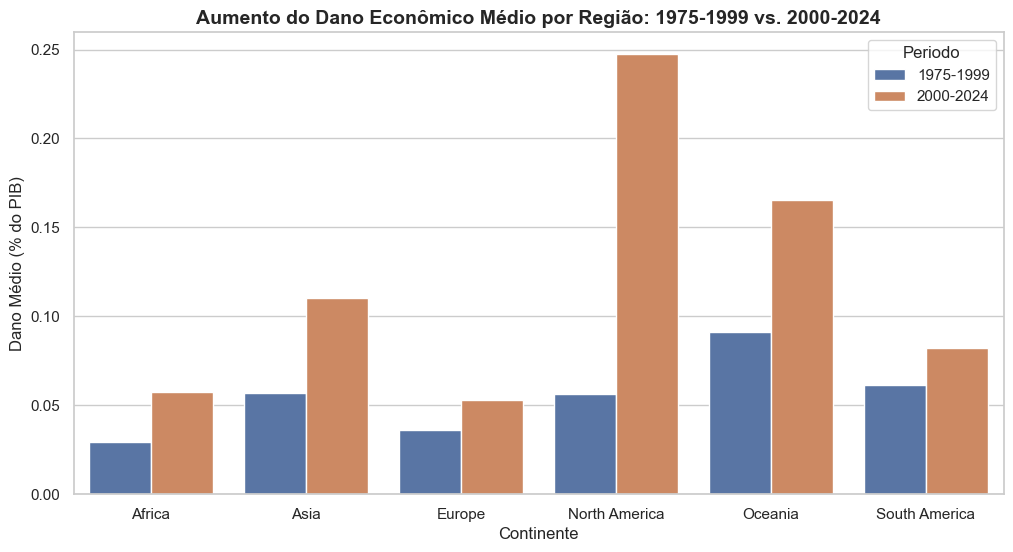

In [199]:
# Criar coluna de períodos (1975-1999 e 2000-2024)
economic_damages['Periodo'] = economic_damages['Year'].apply(lambda x: '1975-1999' if x <= 1999 else '2000-2024')

# Definir estilo global
sns.set_theme(style="whitegrid")
palette = sns.color_palette("Set2")

plt.figure(figsize=(12, 6))
# Calculando a média de dano total por período e região
economic_damages['Total_Dano'] = economic_damages[['Drought', 'Extreme temperature', 'Flood', 'Storm', 'Wildfire']].sum(axis=1)

sns.barplot(data=economic_damages, x='Region', y='Total_Dano', hue='Periodo', estimator='mean', errorbar=None)

plt.title('Aumento do Dano Econômico Médio por Região: 1975-1999 vs. 2000-2024', fontsize=14, fontweight='bold')
plt.ylabel('Dano Médio (% do PIB)')
plt.xlabel('Continente')
plt.show()

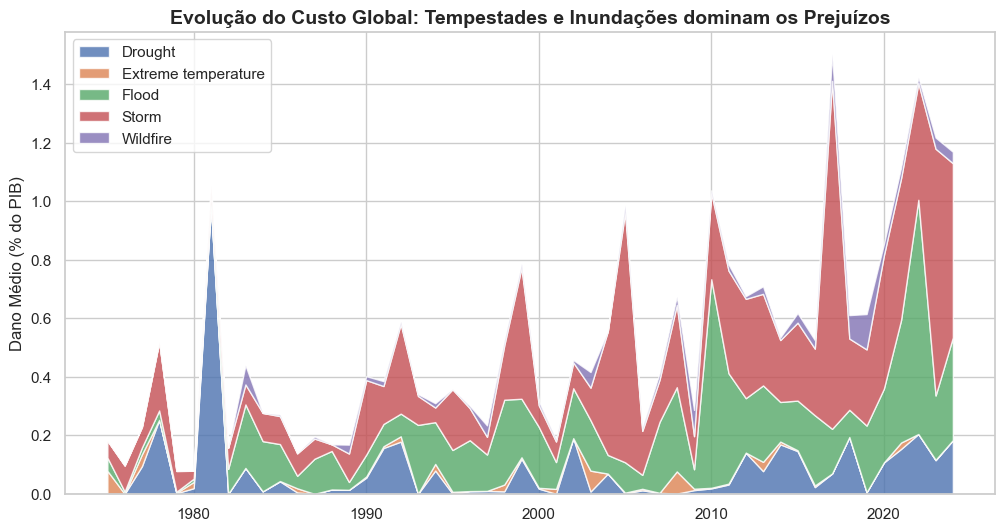

In [200]:
# Preparar dados globais por ano
global_type = economic_damages.groupby('Year')[['Drought', 'Extreme temperature', 'Flood', 'Storm', 'Wildfire']].sum()

plt.figure(figsize=(12, 6))
plt.stackplot(global_type.index, 
              global_type['Drought'], global_type['Extreme temperature'], 
              global_type['Flood'], global_type['Storm'], global_type['Wildfire'],
              labels=global_type.columns, alpha=0.8)

plt.title('Evolução do Custo Global: Tempestades e Inundações dominam os Prejuízos', fontsize=14, fontweight='bold')
plt.legend(loc='upper left')
plt.ylabel('Dano Médio (% do PIB)')
plt.show()

### 2.2. Análise do dataset **Greenhouse gas emissions**

Greenhouse gases são os gases que contribuem para o efeito estufa (CO<sub>2</sub>, Metano e Óxido Nitroso). Os dados contém os a quantidade em toneladas per capita destes gases emitidas por cada país e em cada ano. Também é importante salientar que as emissões são referentes a produção humana destes gases, incluindo a queima de combustíveis fósseis, a atividade industrial e a produção de alimentos.

Citação em linha:

Jones et al. (2025); Population based on various sources (2024) – with major processing by Our World in Data

Citação completa:

Jones et al. (2025); Population based on various sources (2024) – with major processing by Our World in Data. “Per capita greenhouse gas emissions including land use” [dataset]. Jones et al., “National contributions to climate change 2025.1”; Various sources, “Population” [original data].

In [201]:
display(greenhouse_gas_emissions.info())

continent_codes = ['OWID_AFR', 'OWID_ASI', 'OWID_EUR', 'OWID_NAM', 'OWID_OCE', 'OWID_SAM']

gas_emissions_1 = greenhouse_gas_emissions[greenhouse_gas_emissions.Code.isin(continent_codes)].copy()

gas_emissions_1.columns = ['Region', 'Code', 'Year', 'Greenhouse gas emissions']

# Eliminar as linhas cujo anos seja anterior a 1975 e posterior a 2024
gas_emissions_1 = gas_emissions_1[gas_emissions_1['Year'].between(1975, 2024)]
gas_emissions_1 = gas_emissions_1.drop(columns=['Code'])

gas_emissions_1.info()
display(gas_emissions_1.describe())
display(gas_emissions_1)

<class 'pandas.DataFrame'>
RangeIndex: 36179 entries, 0 to 36178
Data columns (total 4 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   Entity                                                  36179 non-null  str    
 1   Code                                                    36179 non-null  str    
 2   Year                                                    36179 non-null  int64  
 3   Per capita greenhouse gas emissions including land use  36179 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 1.1 MB


None

<class 'pandas.DataFrame'>
Index: 300 entries, 300 to 29968
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Region                    300 non-null    str    
 1   Year                      300 non-null    int64  
 2   Greenhouse gas emissions  300 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 9.4 KB


,Year,Greenhouse gas emissions
count,300.000000,300.000000
mean,1999.500000,12.354890
std,14.454981,7.465449
min,1975.000000,3.148923
25%,1987.000000,4.657866
50%,1999.500000,11.231280
75%,2012.000000,18.254743
max,2024.000000,32.317127


,Region,Year,Greenhouse gas emissions
300,Africa,1975,4.913611
301,Africa,1976,4.915044
302,Africa,1977,5.011398
303,Africa,1978,4.752050
304,Africa,1979,4.752768
...,...,...,...
29964,South America,2020,9.278587
29965,South America,2021,9.890444
29966,South America,2022,10.090818
29967,South America,2023,9.877732


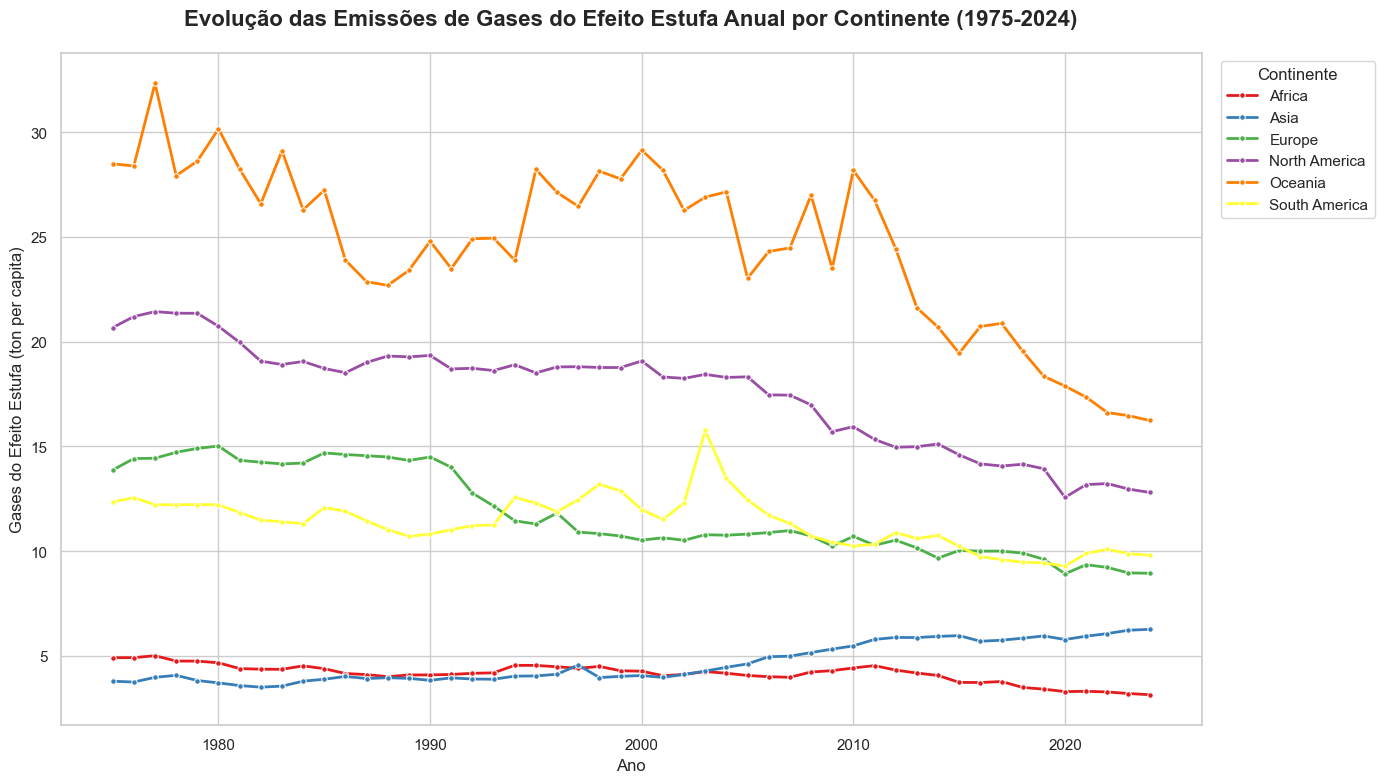

In [202]:
# Criar um gráfico de linhas para mostrar a evolução das anomalias médias nas temperaturas médias anuais por continente
# 1. Configurar o estilo visual para ficar profissional (padrão IEEE)
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid") # Adiciona grades para facilitar a leitura

# 2. Criar o gráfico de linhas
# 'hue' define uma cor diferente para cada continente (Region)
line_plot = sns.lineplot(
    data=gas_emissions_1, 
    x='Year', 
    y='Greenhouse gas emissions', 
    hue='Region', 
    marker='o',         # Adiciona marcadores nos pontos anuais
    markersize=4, 
    linewidth=2,
    palette='Set1'      # Paleta de cores com alto contraste
)

# 3. Customização e Títulos
plt.title('Evolução das Emissões de Gases do Efeito Estufa Anual por Continente (1975-2024)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Gases do Efeito Estufa (ton per capita)', fontsize=12)

# 4. Ajustar a Legenda para fora do gráfico para não obstruir os dados
plt.legend(title='Continente', title_fontsize='12', fontsize='11', bbox_to_anchor=(1.01, 1), loc='upper left')

# 5. Ajuste fino do layout e exibição
plt.tight_layout()
plt.show()

### 2.3. Análise do dataset **Surface temperature**

In [203]:
display(surface_temperature.head())

# 1. Converter a coluna 'Day' para o formato datetime
surface_temperature['Day'] = pd.to_datetime(surface_temperature['Day'])

# 2. Criar a nova coluna 'Year' extraindo apenas o ano (formato YYYY)
surface_temperature['Year'] = surface_temperature['Day'].dt.strftime('%Y')

# Agrupando por Ano e Código, calculando média e mediana para comparação
surface_temperature_1 = surface_temperature.groupby(['Year', 'Code'])['Monthly average'].mean().reset_index()

# Renomeando as colunas para clareza
surface_temperature_1.columns = ['Year', 'Code', 'Yearly average']

# Visualizar o resultado
display(surface_temperature_1.head())

# Eliminar as linhas que correspondem a regiões globais (OWID) e adicionar uma coluna de região (continente)
surface_temperature_2 = surface_temperature_1[~surface_temperature_1.Code.str.startswith('OWID')].copy()
surface_temperature_2['Region'] = surface_temperature_2['Code'].apply(country_to_continent)

# Converter a coluna 'Year' para inteiro
surface_temperature_2['Year'] = surface_temperature_2['Year'].astype(int)

# Agrupar os dados por região e ano, somando os valores dos desastres para cada região
surface_temperature_2 = surface_temperature_2.drop(columns=['Code'])
surface_temperature_2 = surface_temperature_2.groupby(['Region', 'Year'])['Yearly average'].median().reset_index()

# Eliminar as linhas cujo anos seja anterior a 1975 e posterior a 2024
surface_temperature_2 = surface_temperature_2[surface_temperature_2['Year'].between(1975, 2024)].reset_index()
surface_temperature_2.drop(columns=['index'], inplace=True)

surface_temperature_2.info()
display(surface_temperature_2.describe())
display(surface_temperature_2.head())

,Entity,Code,Day,Monthly average
0,Afghanistan,AFG,1940-01-15,-2.032494
1,Afghanistan,AFG,1940-02-15,-0.733503
2,Afghanistan,AFG,1940-03-15,1.999134
3,Afghanistan,AFG,1940-04-15,10.199754
4,Afghanistan,AFG,1940-05-15,17.942135


,Year,Code,Yearly average
0,1940,AFG,11.327695
1,1940,AGO,21.409697
2,1940,AIA,25.821704
3,1940,ALB,10.648014
4,1940,AND,3.409269


<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Region          350 non-null    str    
 1   Year            350 non-null    int64  
 2   Yearly average  350 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 8.3 KB


,Year,Yearly average
count,350.000000,350.000000
mean,1999.500000,17.945347
std,14.451529,8.404539
min,1975.000000,1.074509
25%,1987.000000,9.820079
50%,1999.500000,20.631719
75%,2012.000000,24.676488
max,2024.000000,26.185329


,Region,Year,Yearly average
0,Africa,1975,23.463053
1,Africa,1976,23.532817
2,Africa,1977,23.945950
3,Africa,1978,23.778325
4,Africa,1979,23.850431


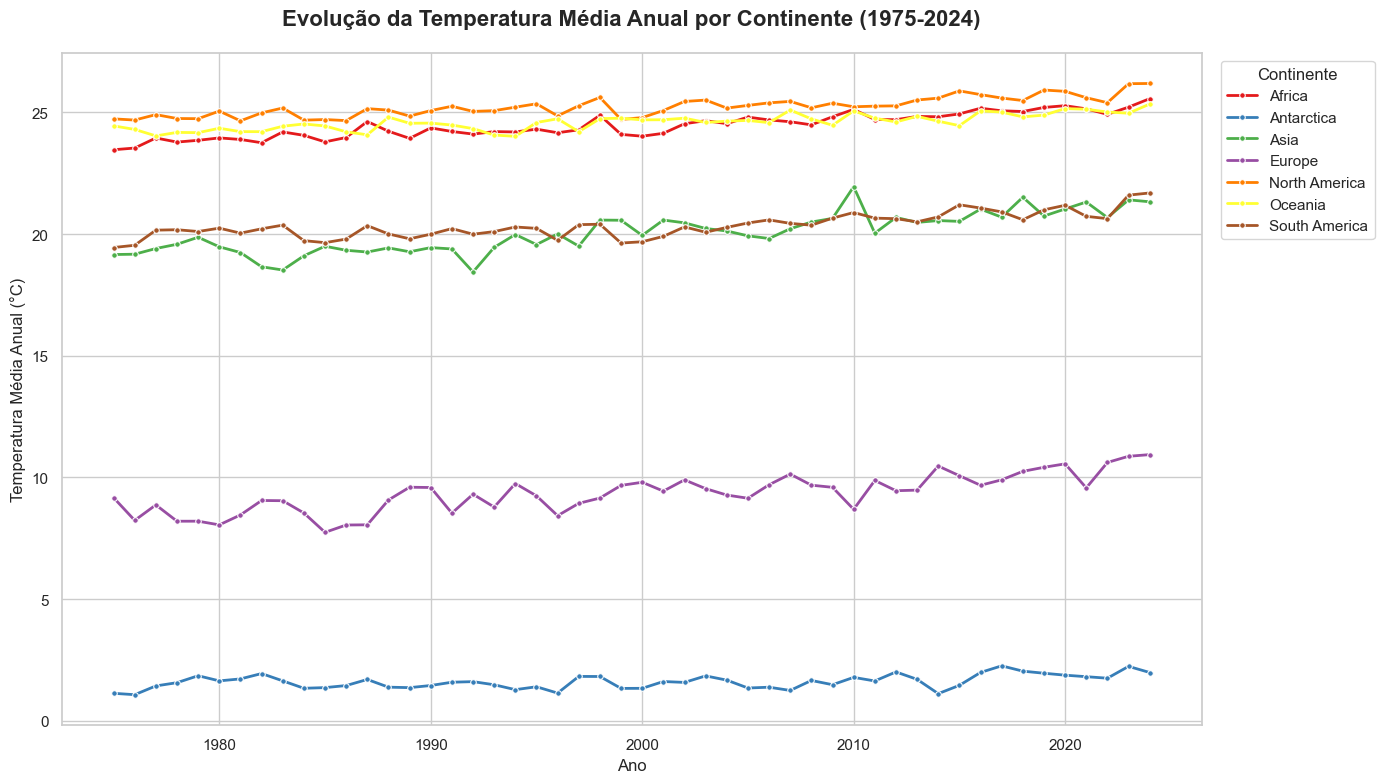

In [204]:
# Criar um gráfico de linhas para mostrar a evolução das temperaturas médias anuais por continente
# 1. Configurar o estilo visual para ficar profissional (padrão IEEE)
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid") # Adiciona grades para facilitar a leitura

# 2. Criar o gráfico de linhas
# 'hue' define uma cor diferente para cada continente (Region)
line_plot = sns.lineplot(
    data=surface_temperature_2, 
    x='Year', 
    y='Yearly average', 
    hue='Region', 
    marker='o',         # Adiciona marcadores nos pontos anuais
    markersize=4, 
    linewidth=2,
    palette='Set1'      # Paleta de cores com alto contraste
)

# 3. Customização e Títulos
plt.title('Evolução da Temperatura Média Anual por Continente (1975-2024)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Temperatura Média Anual (°C)', fontsize=12)

# 4. Ajustar a Legenda para fora do gráfico para não obstruir os dados
plt.legend(title='Continente', title_fontsize='12', fontsize='11', bbox_to_anchor=(1.01, 1), loc='upper left')

# 5. Ajuste fino do layout e exibição
plt.tight_layout()
plt.show()

### 2.4. Análise do dataset **Temperature Anomalies**

In [205]:
display(temperature_anomalies.head())

# 1. Definir a lista de colunas dos meses
colunas_meses = [
    "January", "February", "March", "April", "May", "June", 
    "July", "August", "September", "October", "November", "December"
]

# 2. Calcular a média anual apenas para estas colunas e criar a nova coluna
# O axis=1 indica que a média é calculada horizontalmente (para cada linha)
temperature_anomalies['Yearly_anomaly_average'] = temperature_anomalies[colunas_meses].mean(axis=1)
temperature_anomalies_1 = temperature_anomalies.drop(columns=colunas_meses)

regions = [
    'Africa (NIAID)', 'Asia (NIAID)', 'Europe (NIAID)', 
    'North America (NIAID)', 'South America (NIAID)', 'Oceania (NIAID)'
]

# 2. Filtrar o DataFrame para manter apenas essas entidades
temperature_anomalies_2 = temperature_anomalies_1[temperature_anomalies_1['Entity'].isin(regions)].copy()

# 3. Limpar os nomes (remover o " (NIAID)") para facilitar a visualização
temperature_anomalies_2['Entity'] = temperature_anomalies_2['Entity'].str.replace(' (NIAID)', '', regex=False)

# Eliminar a coluna code
temperature_anomalies_3 = temperature_anomalies_2.drop(columns=['Code'])

# Renomeando as colunas para clareza
temperature_anomalies_3.columns = ['Region', 'Year', 'Yearly anomaly average']

# Eliminar as linhas cujo anos seja anterior a 1975 e posterior a 2024
temperature_anomalies_3 = temperature_anomalies_3[temperature_anomalies_3['Year'].between(1975, 2024)]

# 4. Verificar o resultado
temperature_anomalies_3.info()
display(temperature_anomalies_3.describe())
display(temperature_anomalies_3)

,Entity,Code,Year,January,February,March,April,May,June,July,August,September,October,November,December
0,Afghanistan,AFG,1940,-0.789005,-1.594132,-4.561447,-2.868090,-0.813093,0.006361,-0.850492,-1.840513,-1.719229,0.608858,-0.174298,0.167288
1,Afghanistan,AFG,1941,-1.396612,1.839120,0.525898,-0.109256,1.631727,1.473896,0.133833,0.881645,-0.350918,2.870823,0.891722,1.145056
2,Afghanistan,AFG,1942,0.578493,-0.183040,0.761576,0.712292,1.280947,0.068129,0.535709,-0.487333,-0.290590,1.114729,2.106128,-1.931792
3,Afghanistan,AFG,1943,-2.199644,-2.021629,-1.286101,-3.617765,-2.613882,-1.148052,0.082497,-0.607708,-0.366194,-0.684995,0.362292,2.038275
4,Afghanistan,AFG,1944,-0.124280,-0.487659,0.154415,-0.629282,0.376087,-0.226828,1.443995,0.210638,-1.555296,-0.398036,0.714622,-4.114528


<class 'pandas.DataFrame'>
Index: 300 entries, 122 to 15309
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Region                  300 non-null    str    
 1   Year                    300 non-null    int64  
 2   Yearly anomaly average  300 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 9.4 KB


,Year,Yearly anomaly average
count,300.000000,300.000000
mean,1999.500000,-0.154110
std,14.454981,0.610342
min,1975.000000,-2.037397
25%,1987.000000,-0.529198
50%,1999.500000,-0.118187
75%,2012.000000,0.226582
max,2024.000000,1.396511


,Region,Year,Yearly anomaly average
122,Africa,1975,-1.207231
123,Africa,1976,-1.228984
124,Africa,1977,-0.872081
125,Africa,1978,-0.863768
126,Africa,1979,-0.628132
...,...,...,...
15305,South America,2020,0.401606
15306,South America,2021,0.134192
15307,South America,2022,-0.086281
15308,South America,2023,0.730735


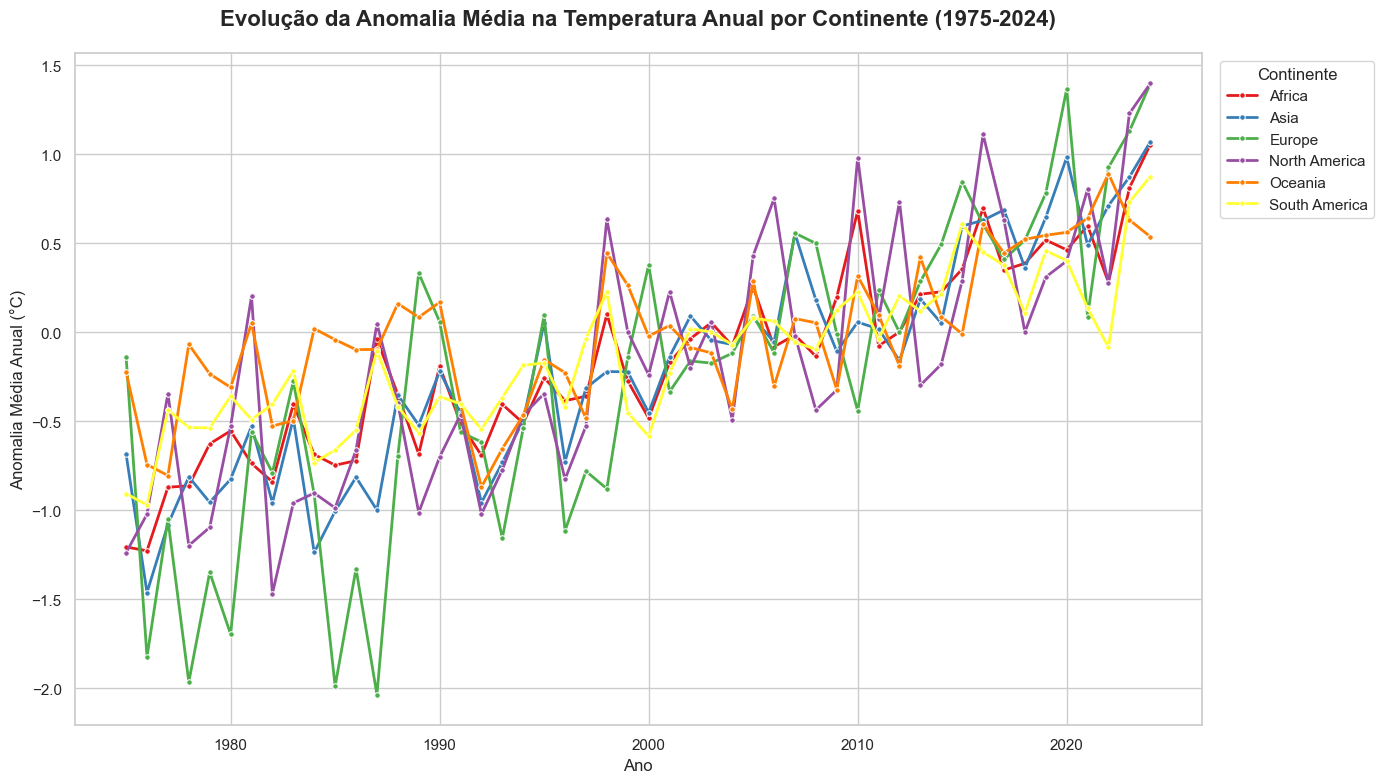

In [206]:
# Criar um gráfico de linhas para mostrar a evolução das anomalias médias nas temperaturas médias anuais por continente
# 1. Configurar o estilo visual para ficar profissional (padrão IEEE)
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid") # Adiciona grades para facilitar a leitura

# 2. Criar o gráfico de linhas
# 'hue' define uma cor diferente para cada continente (Region)
line_plot = sns.lineplot(
    data=temperature_anomalies_3, 
    x='Year', 
    y='Yearly anomaly average', 
    hue='Region', 
    marker='o',         # Adiciona marcadores nos pontos anuais
    markersize=4, 
    linewidth=2,
    palette='Set1'      # Paleta de cores com alto contraste
)

# 3. Customização e Títulos
plt.title('Evolução da Anomalia Média na Temperatura Anual por Continente (1975-2024)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Anomalia Média Anual (°C)', fontsize=12)

# 4. Ajustar a Legenda para fora do gráfico para não obstruir os dados
plt.legend(title='Continente', title_fontsize='12', fontsize='11', bbox_to_anchor=(1.01, 1), loc='upper left')

# 5. Ajuste fino do layout e exibição
plt.tight_layout()
plt.show()